In [6]:
pip install  prophet

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred):
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [8]:
pjme = pd.read_csv('/content/PJME_hourly.csv',
                   index_col=[0],
                  parse_dates=[0])
pjme.head()

,PJME_MW
Datetime,
2002-12-31 01:00:00,26498.0
2002-12-31 02:00:00,25147.0
2002-12-31 03:00:00,24574.0
2002-12-31 04:00:00,24393.0
2002-12-31 05:00:00,24860.0


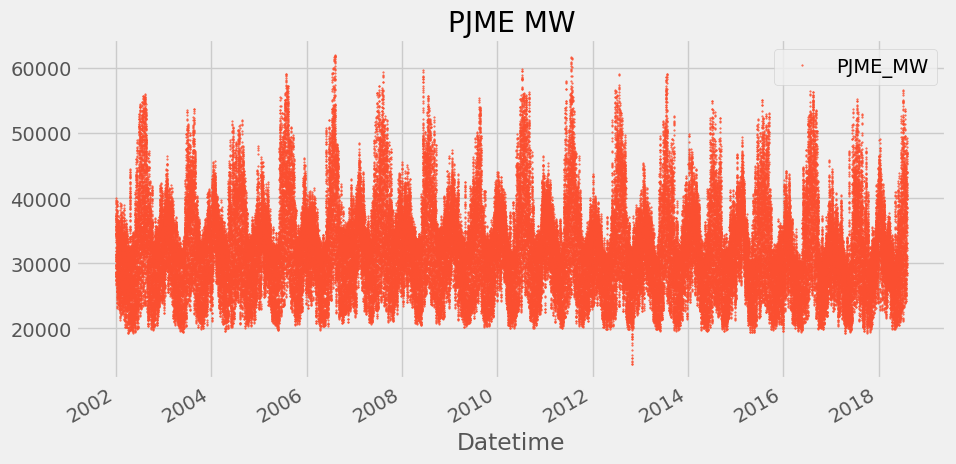

In [9]:
color_pal = sns.color_palette()

pjme.plot(
    style='.',
    figsize=(10, 5),
    ms=1,
    color=color_pal[1],
    title='PJME MW'
)

plt.show()

In [13]:
from pandas.api.types import CategoricalDtype

cat_type = CategoricalDtype(categories=['Monday','Tuesday',
                                        'Wednesday',
                                        'Thursday','Friday',
                                        'Saturday','Sunday'],
                            ordered=True)

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['date'] = df.index
    df['hour'] = df['date'].dt.hour
    df['dayofweek'] = df['date'].dt.dayofweek
    df['weekday'] = df['date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['date'].dt.quarter
    df['month'] = df['date'].dt.month
    df['year'] = df['date'].dt.year
    df['dayofyear'] = df['date'].dt.dayofyear
    df['dayofmonth'] = df['date'].dt.day
    df['weekofyear'] = df['date'].dt.isocalendar().week
    df['date_offset'] = (df.date.dt.month*100 + df.date.dt.day - 320)%1300
    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300],
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    X = df[['hour','dayofweek','quarter','month','year',
           'dayofyear','dayofmonth','weekofyear','weekday',
           'season']]
    if label:
        y = df[label]
        return X, y
    return X

X, y = create_features(pjme, label='PJME_MW')
features_and_target = pd.concat([X, y], axis=1)

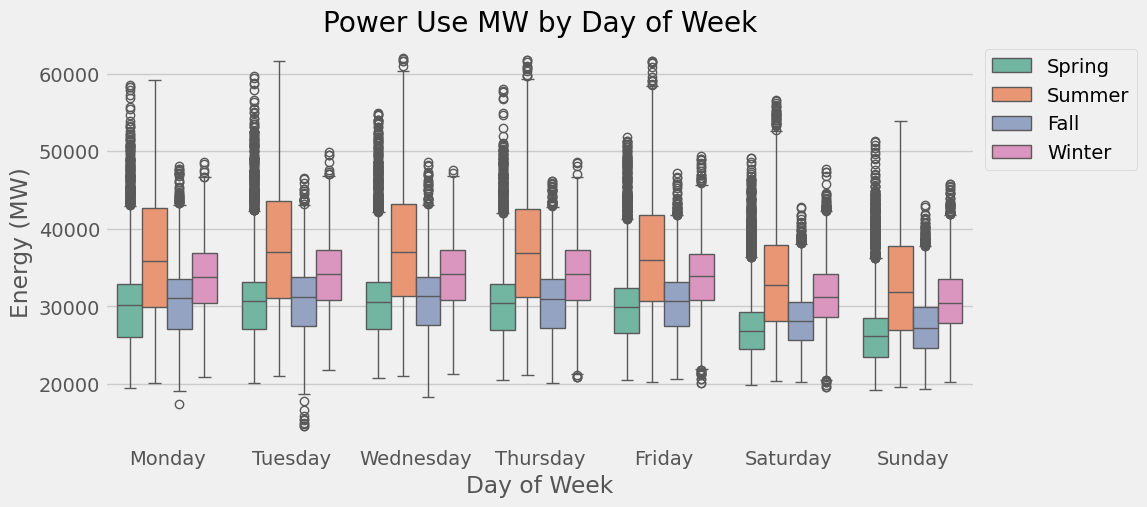

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=features_and_target.dropna(),
    x='weekday',
    y='PJME_MW',
    hue='season',
    ax=ax,
    linewidth=1,
    palette='Set2'
)
ax.set_title('Power Use MW by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Energy (MW)')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

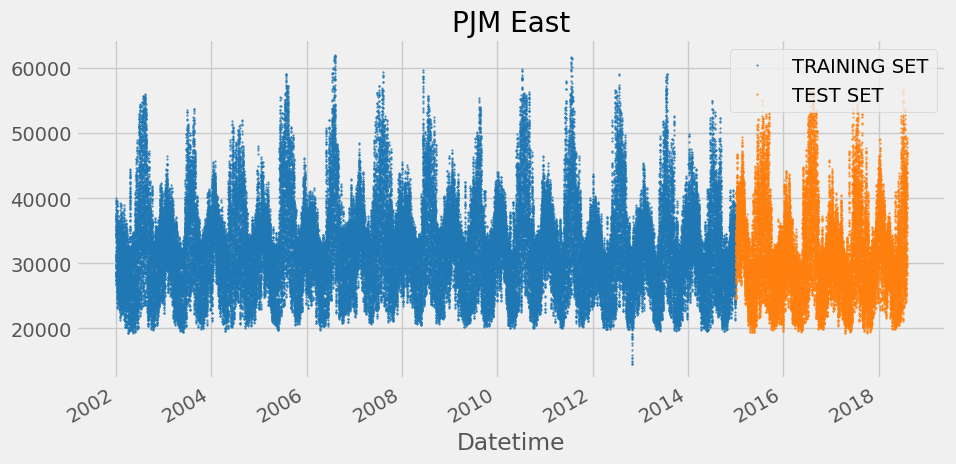

In [15]:
split_date = '1-Jan-2015'
pjme_train = pjme.loc[pjme.index <= split_date].copy()
pjme_test = pjme.loc[pjme.index > split_date].copy()

# Join and rename for plotting
plot_df = pjme_test.rename(columns={'PJME_MW': 'TEST SET'}) \
    .join(pjme_train.rename(columns={'PJME_MW': 'TRAINING SET'}), how='outer')

# Plot with custom colors
plot_df[['TRAINING SET', 'TEST SET']].plot(
    figsize=(10, 5),
    title='PJM East',
    style='.',
    ms=1,
    color=['#1f77b4', '#ff7f0e']
)

plt.show()

In [16]:
train_prophet = pjme_train.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'PJME_MW':'y'})

In [17]:
model = Prophet()
model.fit(train_prophet)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp64nxujkm/nf_ppu_h.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp64nxujkm/ibhq4cms.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=23590', 'data', 'file=/tmp/tmp64nxujkm/nf_ppu_h.json', 'init=/tmp/tmp64nxujkm/ibhq4cms.json', 'output', 'file=/tmp/tmp64nxujkm/prophet_modelu122euz4/prophet_model-20250503142013.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:20:13 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:21:44 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [18]:
test_prophet = pjme_test.reset_index() \
    .rename(columns={'Datetime':'ds',
                     'PJME_MW':'y'})

test_fcst = model.predict(test_prophet)

In [19]:
test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,daily,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-01 01:00:00,31210.530967,23608.270505,32930.472750,31210.530967,31210.530967,-2893.742472,-2893.742472,-2893.742472,-4430.272423,...,1281.328732,1281.328732,1281.328732,255.201219,255.201219,255.201219,0.0,0.0,0.0,28316.788495
1,2015-01-01 02:00:00,31210.494154,22377.702220,31321.445916,31210.494154,31210.494154,-4398.239425,-4398.239425,-4398.239425,-5927.272577,...,1272.574102,1272.574102,1272.574102,256.459050,256.459050,256.459050,0.0,0.0,0.0,26812.254729
2,2015-01-01 03:00:00,31210.457342,21610.870725,30236.118870,31210.457342,31210.457342,-5269.974485,-5269.974485,-5269.974485,-6790.346308,...,1262.613389,1262.613389,1262.613389,257.758434,257.758434,257.758434,0.0,0.0,0.0,25940.482857
3,2015-01-01 04:00:00,31210.420529,21415.336039,30457.644688,31210.420529,31210.420529,-5411.456410,-5411.456410,-5411.456410,-6922.126021,...,1251.570211,1251.570211,1251.570211,259.099400,259.099400,259.099400,0.0,0.0,0.0,25798.964119
4,2015-01-01 05:00:00,31210.383716,21859.369433,30917.665647,31210.383716,31210.383716,-4737.018106,-4737.018106,-4737.018106,-6237.080479,...,1239.580401,1239.580401,1239.580401,260.481971,260.481971,260.481971,0.0,0.0,0.0,26473.365610


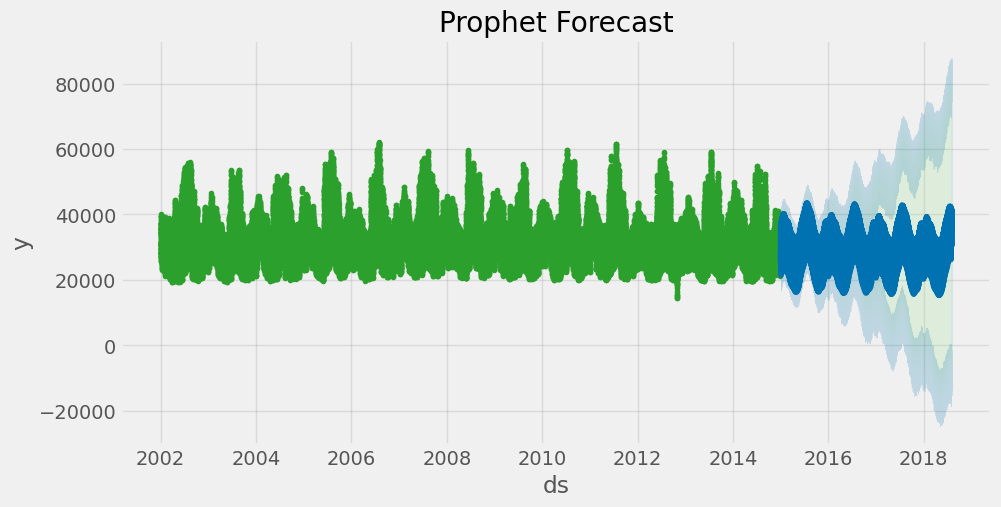

In [21]:
line_color = '#2ca02c'         # Green for forecast line
uncertainty_color = '#98df8a'  # Light green for uncertainty

# Create plot
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(test_fcst, ax=ax)

# Update line and uncertainty fill colors
lines = ax.get_lines()
if lines:
    lines[0].set_color(line_color)  # Forecast line

# Fill between (confidence interval)
for collection in ax.collections:
    collection.set_facecolor(uncertainty_color)
    collection.set_alpha(0.2)

ax.set_title('Prophet Forecast')
plt.show()

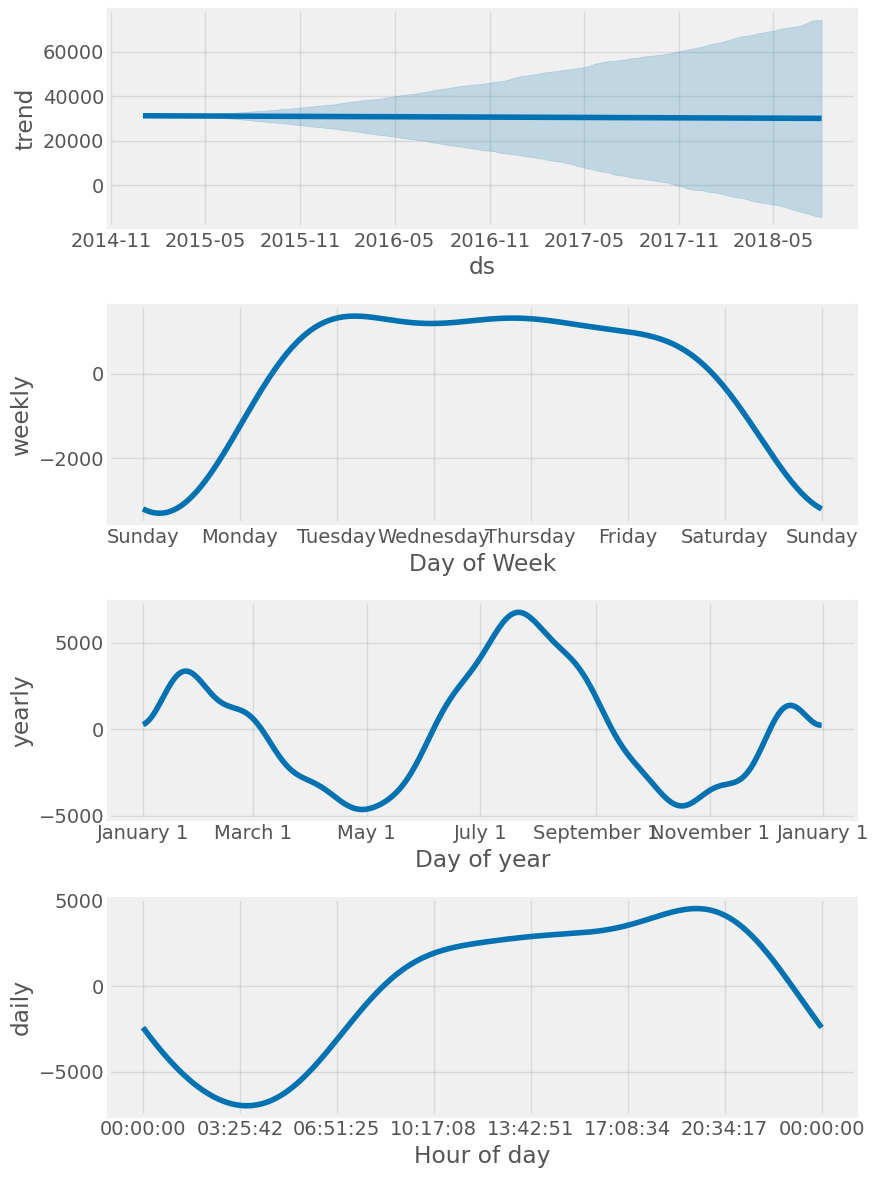

In [22]:
fig = model.plot_components(test_fcst)
plt.show()

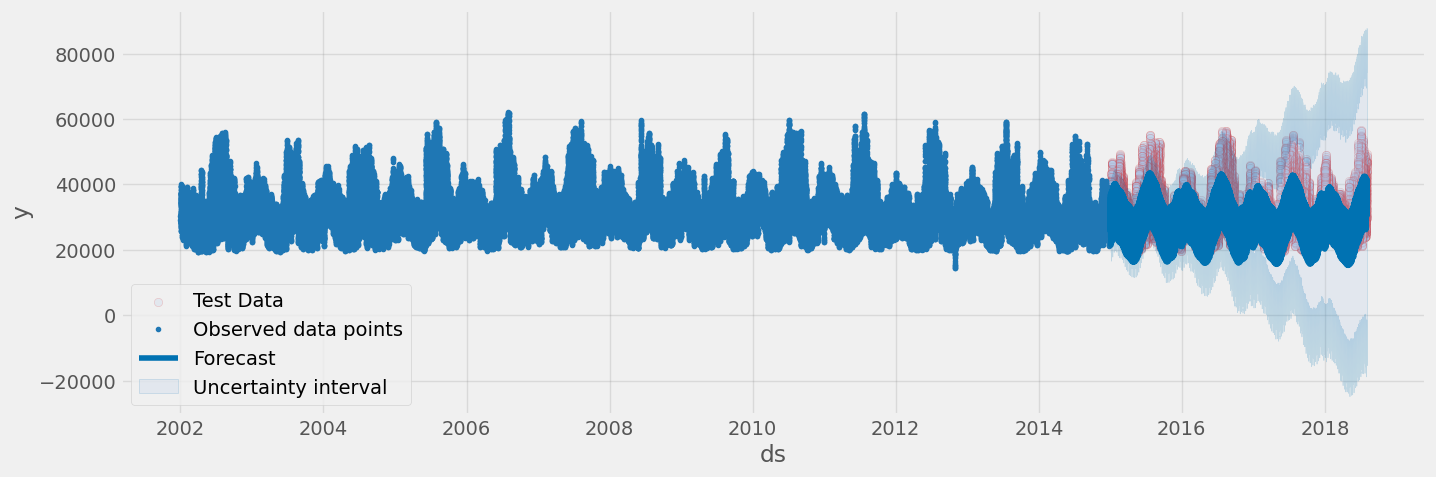

In [24]:
# Define custom colors
scatter_color = '#d62728'       # Red for test data points
forecast_line_color = '#1f77b4' # Blue for forecast line
uncertainty_color = '#aec7e8'   # Light blue for uncertainty

# Create figure and plot
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color=scatter_color, label='Test Data')

# Prophet forecast plot
fig = model.plot(test_fcst, ax=ax)

# Change forecast line color
lines = ax.get_lines()
if lines:
    lines[0].set_color(forecast_line_color)  # Forecast line

# Change uncertainty interval color
for collection in ax.collections:
    collection.set_facecolor(uncertainty_color)
    collection.set_alpha(0.2)

ax.legend()
plt.show()

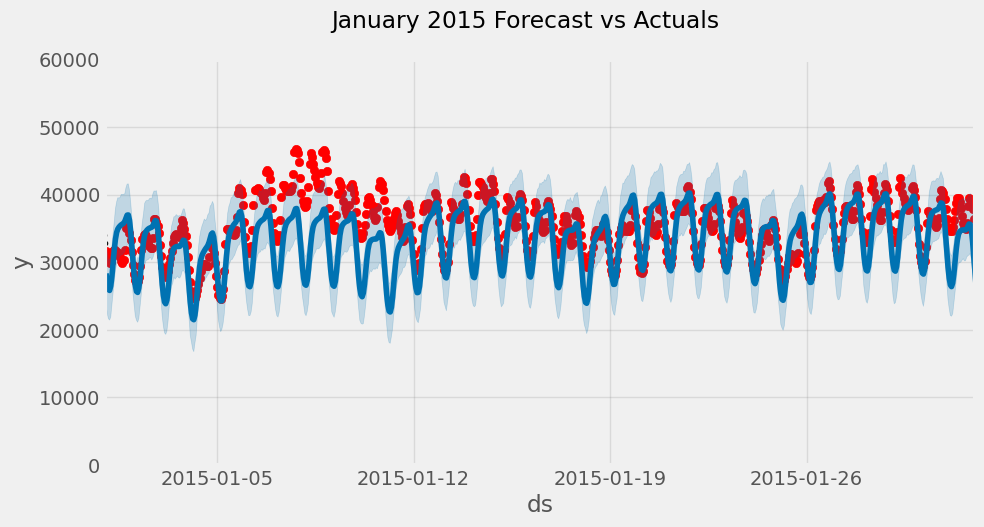

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(test_fcst, ax=ax)
# Convert the date strings to pandas Timestamp objects
ax.set_xbound(lower=pd.Timestamp('2015-01-01'), upper=pd.Timestamp('2015-02-01'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('January 2015 Forecast vs Actuals')

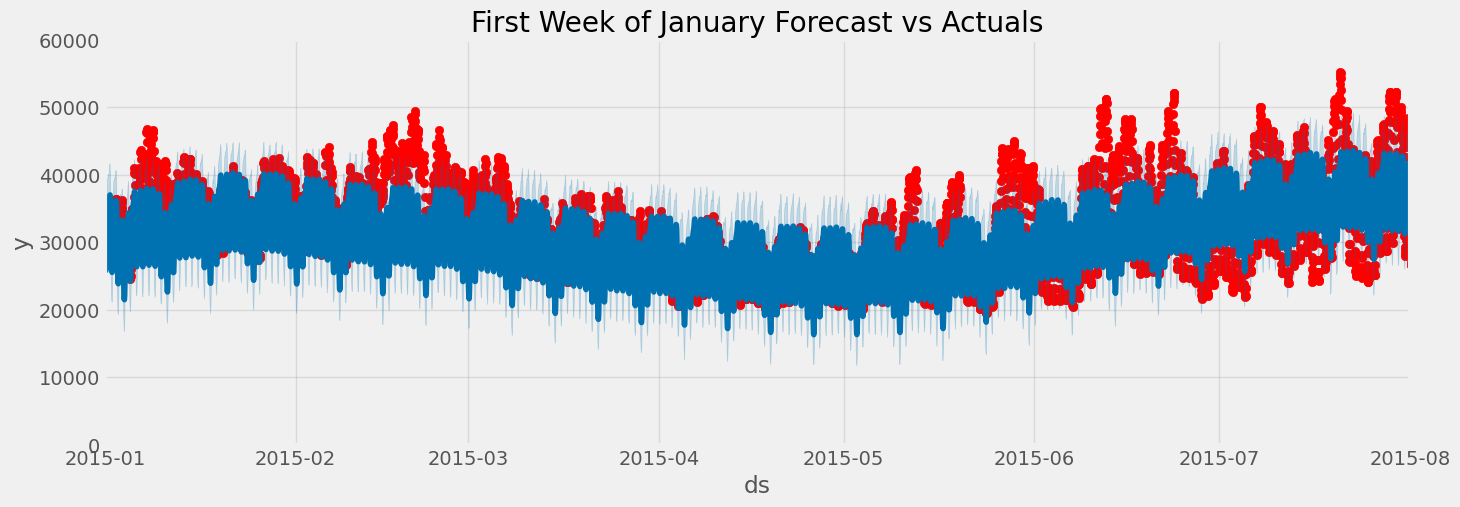

In [33]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(test_fcst, ax=ax)
ax.set_xbound(lower=pd.Timestamp('2015-01-01'), upper=pd.Timestamp('2015-08-01'))
ax.set_ylim(0, 60000)
ax.set_title('First Week of January Forecast vs Actuals')
plt.show()

In [34]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'],
                   y_pred=test_fcst['yhat']))

np.float64(6616.966074225221)

In [35]:
mean_absolute_error(y_true=pjme_test['PJME_MW'],
                   y_pred=test_fcst['yhat'])

5181.911537928106

In [36]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'],
                   y_pred=test_fcst['yhat'])

np.float64(16.512003880182647)

In [37]:
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar

cal = calendar()


holidays = cal.holidays(start=pjme.index.min(),
                        end=pjme.index.max(),
                        return_name=True)
holiday_df = pd.DataFrame(data=holidays,
                          columns=['holiday'])
holiday_df = holiday_df.reset_index().rename(columns={'index':'ds'})

In [39]:
%%time
model_with_holidays = Prophet(holidays=holiday_df)
model_with_holidays.fit(train_prophet)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp64nxujkm/9lek0qt7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp64nxujkm/ucb32qjo.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=26575', 'data', 'file=/tmp/tmp64nxujkm/9lek0qt7.json', 'init=/tmp/tmp64nxujkm/ucb32qjo.json', 'output', 'file=/tmp/tmp64nxujkm/prophet_modelgjs1refl/prophet_model-20250503143455.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
14:34:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
14:37:27 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


CPU times: user 12.4 s, sys: 832 ms, total: 13.2 s
Wall time: 2min 44s


In [40]:
pjme_test_fcst_with_hols = \
    model_with_holidays.predict(df=test_prophet)

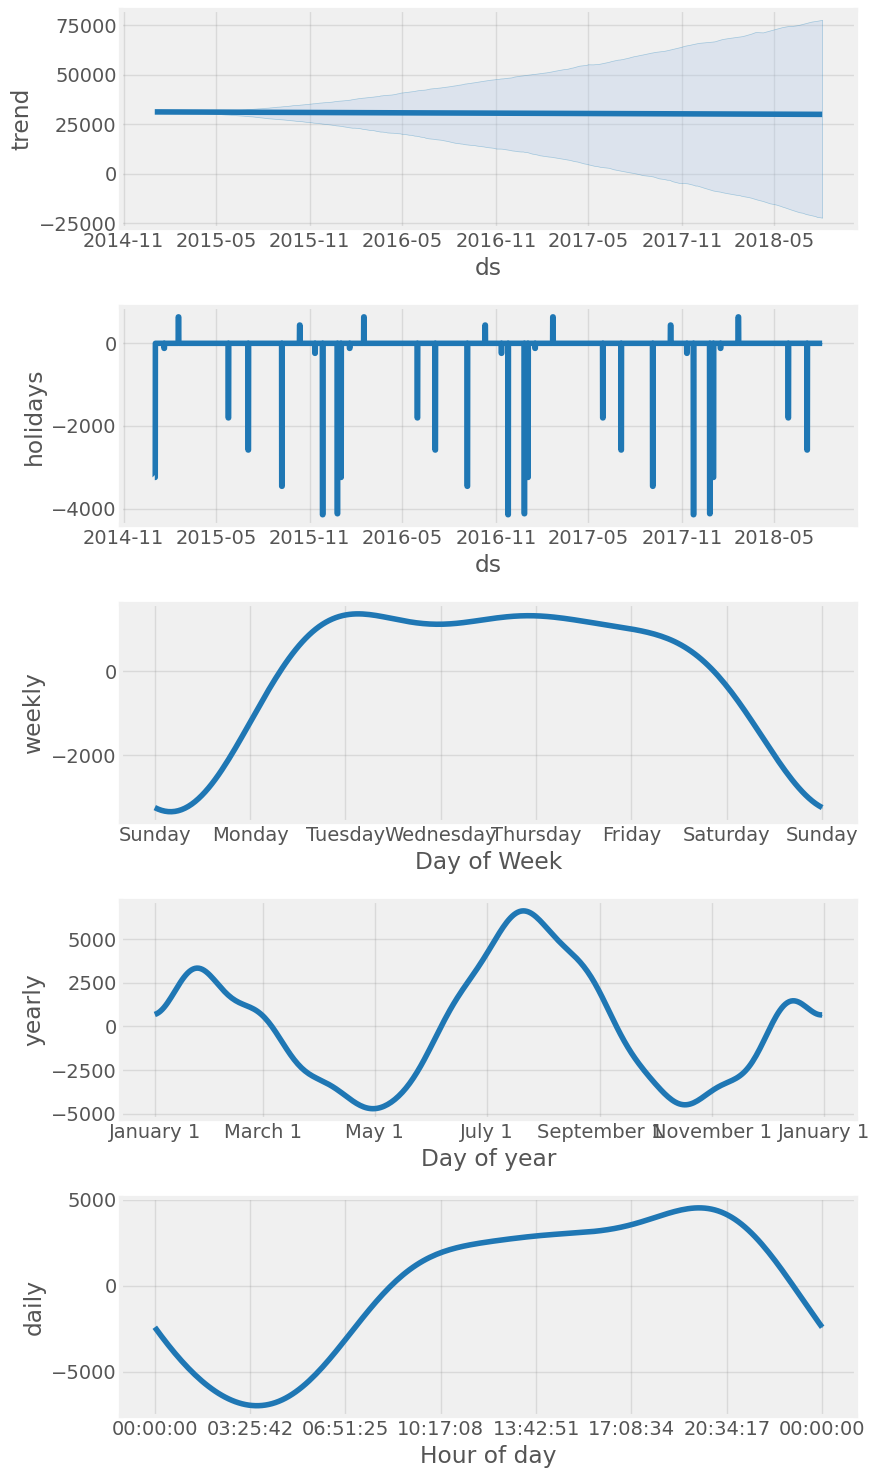

In [41]:
fig = model_with_holidays.plot_components(pjme_test_fcst_with_hols)

# Custom colors
line_color = '#1f77b4'       # Blue for lines
fill_color = '#aec7e8'       # Light blue for fill/uncertainty

# Loop through axes in the figure
for ax in fig.get_axes():
    # Change line colors
    for line in ax.lines:
        line.set_color(line_color)

    # Change fill color (usually for uncertainty intervals)
    for collection in ax.collections:
        collection.set_facecolor(fill_color)
        collection.set_alpha(0.3)

plt.show()

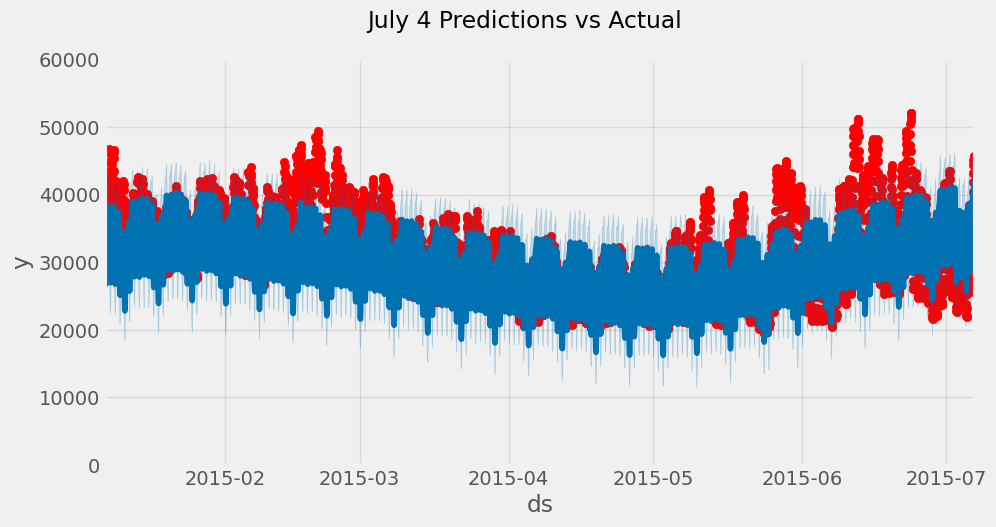

In [42]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pjme_test.index, pjme_test['PJME_MW'], color='r')
fig = model.plot(pjme_test_fcst_with_hols, ax=ax)
# Convert the date strings to pandas Timestamp objects
ax.set_xbound(lower=pd.Timestamp('2015-01-07'), upper=pd.Timestamp('2015-07-07'))
ax.set_ylim(0, 60000)
plot = plt.suptitle('July 4 Predictions vs Actual')

In [43]:
np.sqrt(mean_squared_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst_with_hols['yhat']))

np.float64(6639.587205626055)

In [44]:
mean_absolute_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst_with_hols['yhat'])

5201.46462763833

In [45]:
mean_absolute_percentage_error(y_true=pjme_test['PJME_MW'],
                   y_pred=pjme_test_fcst_with_hols['yhat'])

np.float64(16.558807523531467)

In [46]:
future = model.make_future_dataframe(periods=365*24, freq='h', include_history=False)
forecast = model_with_holidays.predict(future)

In [47]:
forecast[['ds','yhat']].head()

,ds,yhat
0,2015-01-01 01:00:00,25567.271675
1,2015-01-01 02:00:00,24065.351481
2,2015-01-01 03:00:00,23195.828972
3,2015-01-01 04:00:00,23056.212620
4,2015-01-01 05:00:00,23732.192245
